In [4]:
import pandas as pd
import numpy as np
from lightgbm import LGBMClassifier
from sklearn.preprocessing import LabelEncoder
# 제출 파일 생성 관련
import os
import zipfile

# 데이터 처리 및 분석
import pandas as pd
import numpy as np
from scipy import stats
from tqdm import tqdm
import seaborn as sns
import matplotlib.pyplot as plt

# 머신러닝 전처리
from sklearn.preprocessing import LabelEncoder, OrdinalEncoder

# 머신러닝 모델
import xgboost as xgb

# 합성 데이터 생성
from sdv.metadata import SingleTableMetadata
from sdv.single_table import CTGANSynthesizer

# To ignore all warnings
import warnings

warnings.filterwarnings('ignore')

import pandas as pd
import numpy as np
from lightgbm import LGBMClassifier
from xgboost import XGBClassifier
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import f1_score


# ✅ 데이터 불러오기 및 전처리
train_all = pd.read_csv("./train_kor1.csv")
test_all = pd.read_csv("./test_kor.csv")
all_synthetic_data = pd.read_csv('./syn_submission.csv')
train = pd.read_csv("./train.csv")
x_id = test_all["샘플 식별자 번호"]
train_all.drop(columns='샘플 식별자 번호', inplace=True, errors='ignore')
a = train_all['직전 거래와의 시간 차이']
train_all.drop(columns='직전 거래와의 시간 차이', inplace=True, errors='ignore')
train_all['직전 거래와의 시간 차이'] = a
train_all.head()
all_synthetic_data.columns = train_all.columns


synth_data_300 = []

for fraud_type in all_synthetic_data['사기 시나리오 (예측 목표)'].unique():
    temp = all_synthetic_data[all_synthetic_data['사기 시나리오 (예측 목표)'] == fraud_type]
    # 만약 500개 이상이면 500개 샘플링, 적으면 전부
    sampled = temp.sample(n=300, random_state=42) if len(temp) >= 300 else temp
    synth_data_300.append(sampled)

synth_data_300=  pd.concat(synth_data_300, ignore_index=True)
# synth_data_300: 라벨별 300개씩(최대), 총 3,900개

# 실제 데이터와 합성 데이터 합치기


all_synthetic_data = synth_data_300





train_all = pd.concat([train_all, all_synthetic_data], ignore_index=True)

train_all.rename(columns={"사기 시나리오 (예측 목표)": "label"}, inplace=True)

drop_cols = ['고객명', '주민번호', '거래에 사용한 단말기 IP주소', '거래에 사용한 단말기 MAC주소',
             '암호화된 계좌번호', '수취인 계좌번호']
train_all.drop(columns=drop_cols, inplace=True, errors='ignore')
test_all.drop(columns=drop_cols, inplace=True, errors='ignore')

In [5]:
train_x = train_all 
test_x = test_all

In [6]:
train_x.shape

(123900, 57)

In [7]:
## 파생변수 추가 코드
# 1. 최근 잔고 급감 여부 (초기 잔고의 70% 이상 하락)
train_x['Is_Sudden_Balance_Drop'] = (train_x['거래 후 잔액'] < train_x['거래 전 잔액'] * 0.3).astype(int)
test_x['Is_Sudden_Balance_Drop'] = (test_x['거래 후 잔액'] < test_x['거래 전 잔액'] * 0.3).astype(int)

# 2. 고액 이체 탐지 (거래금액 / 하루한도 비율)
train_x['Amount_Per_Limit_Ratio'] = train_x['이체 금액'] / (train_x['1일 거래 한도'] + 1)
test_x['Amount_Per_Limit_Ratio'] = test_x['이체 금액'] / (test_x['1일 거래 한도'] + 1)

# 5. (VPN , 루팅 , 로밍) 중 하나이면서, 고객 등급이 C인지 여부
train_x['B_Flag_GradeC_DeviceAnomaly'] = (
    (train_x['고객 등급'] == 'C') &
    ((train_x['모바일 로밍 여부'] == 1) | (train_x['탈옥 및 루팅 여부'] == 1) | (train_x['VPN 사용 여부'] == 1))).astype(int)

test_x['B_Flag_GradeC_DeviceAnomaly'] = (
    (test_x['고객 등급'] == 'C') &
    ((test_x['모바일 로밍 여부'] == 1) |(test_x['탈옥 및 루팅 여부'] == 1) | (test_x['VPN 사용 여부'] == 1))).astype(int)

# 6. 유휴 계좌의 갑작스러운 거래 시도
# train_x['Inactive_Account_Suddenly_Used'] = ((train_x['7일 거래내역 중 미거래 계좌 여부'] == 1) & (train_x['이체 금액'] > 0)).astype(int)
# test_x['Inactive_Account_Suddenly_Used'] = ((test_x['7일 거래내역 중 미거래 계좌 여부'] == 1) & (test_x['이체 금액'] > 0)).astype(int)

# # 7. 접속 실패 후 성공 거래 (3회 이상 실패 시 플래그)
# train_x['High_Connection_Failure_Flag'] = (train_x['거래 시스템 접속 실패 횟수'] >= 3).astype(int)
# test_x['High_Connection_Failure_Flag'] = (test_x['거래 시스템 접속 실패 횟수'] >= 3).astype(int)

# 8. 거래금액 / 최근 한달 최대 거래금액
train_x['Amount_vs_Monthly_Max'] = train_x['이체 금액'] / (train_x['1개월 거래내역 중 최대 이체(출금) 금액'] + 1)
test_x['Amount_vs_Monthly_Max'] = test_x['이체 금액'] / (test_x['1개월 거래내역 중 최대 이체(출금) 금액'] + 1)

# # 11. 동일 수취계좌로 반복 전송 여부 (같은 계좌로 3회 초과 송금)
# transfer_counts_train = train_x.groupby(['암호화된 계좌번호', '수취인 계좌번호']).size().rename('이체횟수')
# train_x = train_x.merge(transfer_counts_train, on=['암호화된 계좌번호', '수취인 계좌번호'], how='left')
# train_x['Same_Account_Repeated_Transfer'] = (train_x['이체횟수'] > 3).astype(int)

# transfer_counts_test = test_x.groupby(['암호화된 계좌번호', '수취인 계좌번호']).size().rename('이체횟수')
# test_x = test_x.merge(transfer_counts_test, on=['암호화된 계좌번호', '수취인 계좌번호'], how='left')
# test_x['Same_Account_Repeated_Transfer'] = (test_x['이체횟수'] > 3).astype(int)

# 12. 고객 나이가 60세 이상이면서, 대출 유형이 담보대출인지 여부
# 기준 연도 설정
current_year = 2024

train_x['고객 나이'] = current_year - train_x['고객 출생년도']
train_x['L_Is_Elderly_Secured_Loan'] = (
    (train_x['고객 나이'] >= 60) & (train_x['대출 신청 유형(a: 없음, b: 신용대출, c: 담보대출, d: 할부금융, e: 기타)'] == 'c')
    ).astype(int)

test_x['고객 나이'] = current_year - test_x['고객 출생년도']
test_x['L_Is_Elderly_Secured_Loan'] = (
    (test_x['고객 나이'] >= 60) & (test_x['대출 신청 유형(a: 없음, b: 신용대출, c: 담보대출, d: 할부금융, e: 기타)'] == 'c')
    ).astype(int)

# A. 거리
train_x['Is_Large_Distance'] = (train_x['직전 거래 발생지와의 거리 차이'] >= 300).astype(int)
train_x['A_VPN_and_Large_Distance'] = (
    ((train_x['거래 시스템 접근 매체(a: ID/PW 로그인, b: 패턴, c: 생체로그인, d: 금융/공동 인증서, e: 사설인증서, f: 보안카드, g: OTP, h: 보안카드+OTP)'] == 'a') | (train_x['거래 시스템 접근 매체(a: ID/PW 로그인, b: 패턴, c: 생체로그인, d: 금융/공동 인증서, e: 사설인증서, f: 보안카드, g: OTP, h: 보안카드+OTP)'] == 'b'))  & (train_x['Is_Large_Distance'] == 1)
    ).astype(int)

test_x['Is_Large_Distance'] = (test_x['직전 거래 발생지와의 거리 차이'] >= 300).astype(int)
test_x['A_VPN_and_Large_Distance'] = (
    ((test_x['거래 시스템 접근 매체(a: ID/PW 로그인, b: 패턴, c: 생체로그인, d: 금융/공동 인증서, e: 사설인증서, f: 보안카드, g: OTP, h: 보안카드+OTP)'] == 'a') | (test_x['거래 시스템 접근 매체(a: ID/PW 로그인, b: 패턴, c: 생체로그인, d: 금융/공동 인증서, e: 사설인증서, f: 보안카드, g: OTP, h: 보안카드+OTP)'] == 'b')) & (test_x['Is_Large_Distance'] == 1)
    ).astype(int)
# B. 고객 등급이 ‘C’이면서, (VPN , 루팅 , 로밍) 중 하나가 사용되었을 경우
train_x['B_Flag_GradeC_DeviceAnomaly'] = (
    (train_x['고객 등급'] == 'C') &
    ((train_x['모바일 로밍 여부'] == 1) | (train_x['탈옥 및 루팅 여부'] == 1) | (train_x['VPN 사용 여부'] == 1))).astype(int)

test_x['B_Flag_GradeC_DeviceAnomaly'] = (
    (test_x['고객 등급'] == 'C') &
    ((test_x['모바일 로밍 여부'] == 1) |(test_x['탈옥 및 루팅 여부'] == 1) | (test_x['VPN 사용 여부'] == 1))).astype(int)

# C. 키로깅을 통한 정보 탈취 거래
train_x['C_Keylogging_Risk'] = ((train_x['거래 시스템 접속 실패 횟수'] >= 3) & (train_x['키로깅 여부'] == 1)).astype(int)
test_x['C_Keylogging_Risk'] = ((test_x['거래 시스템 접속 실패 횟수'] >= 3) & (test_x['키로깅 여부'] == 1)).astype(int)
# D. 7일 거래내역 중 미사용 단말 여부가 1이고, 거래 시스템 접근 매체가 ID /PW 로그인 및 패턴, 거래 성공/실패 여부이 0이고, 에러코드가 0인 경우
train_x['D_Scripted_Like_Transaction'] = (
    (train_x['7일 거래내역 중 미사용 단말 여부'] == 1) &
    (train_x['거래 시스템 접근 매체(a: ID/PW 로그인, b: 패턴, c: 생체로그인, d: 금융/공동 인증서, e: 사설인증서, f: 보안카드, g: OTP, h: 보안카드+OTP)'].isin(['a', 'b'])) &
    (train_x['거래 성공/실패 여부'] == 0) &
    (train_x['에러코드(a: 에러없음, b: 시스템 오류, c: 잔액부족, d: 이체한도초과, e: 계좌정보 오류, f: 계좌이체 거부)'] == 'a')
    ).astype(int)

test_x['D_Scripted_Like_Transaction'] = (
    (test_x['7일 거래내역 중 미사용 단말 여부'] == 1) &
    (test_x['거래 시스템 접근 매체(a: ID/PW 로그인, b: 패턴, c: 생체로그인, d: 금융/공동 인증서, e: 사설인증서, f: 보안카드, g: OTP, h: 보안카드+OTP)'].isin(['a', 'b'])) &
    (test_x['거래 성공/실패 여부'] == 0) &
    (test_x['에러코드(a: 에러없음, b: 시스템 오류, c: 잔액부족, d: 이체한도초과, e: 계좌정보 오류, f: 계좌이체 거부)'] == 'a')
    ).astype(int)
# E. 보이스피싱 인출 시도
train_x['E_Vishing_Withdrawal_Risk'] = ((train_x['거래 채널'] == 'ATM') & (train_x['7일 거래내역 중 1천만원 이상 입금 여부'] == 1)).astype(int)
test_x['E_Vishing_Withdrawal_Risk'] = ((test_x['거래 채널'] == 'ATM') & (test_x['7일 거래내역 중 1천만원 이상 입금 여부'] == 1)).astype(int)

# F. 고액 거래
train_x['G_MoneyLaundering_Risk'] = ((train_x['7일 거래내역 중 1천만원 이상 입금 여부'] == 1) & (train_x['30일 이내 계좌 정지 해제 여부'] == 1) & train_x['거래에 사용한 단말기 OS'] == 'Others').astype(int)
test_x['G_MoneyLaundering_Risk'] = ((test_x['7일 거래내역 중 1천만원 이상 입금 여부'] == 1) & (test_x['30일 이내 계좌 정지 해제 여부'] == 1) & test_x['거래에 사용한 단말기 OS'] == 'Others').astype(int)

train_x['F_MoneyLaundering_Risk'] = (
    (train_x['거래 채널'] == 'Others')
    & (train_x['거래에 사용한 단말기 OS'].isin(['Others', 'Windows']))
    ).astype(int)

test_x['F_MoneyLaundering_Risk'] = (
    (test_x['거래 채널'] == 'Others')
    & (test_x['거래에 사용한 단말기 OS'].isin(['Others', 'Windows']))
    ).astype(int)
# G. 자금세탁 거래
train_x['G_MoneyLaundering_Risk'] = ((train_x['7일 거래내역 중 1천만원 이상 입금 여부'] == 1) & (train_x['30일 이내 계좌 정지 해제 여부'] == 1)).astype(int)
test_x['G_MoneyLaundering_Risk'] = ((test_x['7일 거래내역 중 1천만원 이상 입금 여부'] == 1) & (test_x['30일 이내 계좌 정지 해제 여부'] == 1)).astype(int)

# # H. 소액 분산 이체
# same_amount_counts_train = train_x.groupby(['암호화된 계좌번호', '이체 금액']).size().rename('동일금액이체횟수').reset_index()
# train_x = train_x.merge(same_amount_counts_train, on=['암호화된 계좌번호', '이체 금액'], how='left')
# train_x['H_Repeated_Same_Amount_Transfer'] = (train_x['동일금액이체횟수'] >= 3).astype(int)

# same_amount_counts_test = test_x.groupby(['암호화된 계좌번호', '이체 금액']).size().rename('동일금액이체횟수').reset_index()
# test_x = test_x.merge(same_amount_counts_test, on=['암호화된 계좌번호', '이체 금액'], how='left')
# test_x['H_Repeated_Same_Amount_Transfer'] = (test_x['동일금액이체횟수'] >= 3).astype(int)

# J. 대포통장 거래
train_x['J_Suspicious_Small_Repeated_Transfer'] = ((train_x['수취계좌의 거래중지계좌 해당 여부'] == 1) & (train_x['7일 거래내역 중 미거래 계좌 여부'] == 1)).astype(int)
test_x['J_Suspicious_Small_Repeated_Transfer'] = ((test_x['수취계좌의 거래중지계좌 해당 여부'] == 1) & (test_x['7일 거래내역 중 미거래 계좌 여부'] == 1)).astype(int)

# K. 부업 사기 및 공범 계좌 활용
train_x['K_Affiliate_Scam_Risk'] = ((train_x['3시간 이내 해당 수취계좌에 이체 횟수'] >= 2) & (train_x['해당 수취계좌와 거래한 횟수'] >= 2)).astype(int)
test_x['K_Affiliate_Scam_Risk'] = ((test_x['3시간 이내 해당 수취계좌에 이체 횟수'] >= 2) & (test_x['해당 수취계좌와 거래한 횟수'] >= 2)).astype(int)


In [8]:
def add_custom_features_0(df):
    current_year = 2024
    # 📌 1. 고객 나이
    df['고객 나이'] = current_year - df['고객 출생년도']
    # 📌 2. 거리 관련 변수
    df['Is_Large_Distance'] = (df['직전 거래 발생지와의 거리 차이'] >= 300).astype(int)
    
    # 📌 3. A
    vpn_login_types = ['a', 'b']
    df['Is_Large_Distance'] = (df['직전 거래 발생지와의 거리 차이'] >= 300).astype(int)
    df['A'] = (
            df['거래 시스템 접근 매체(a: ID/PW 로그인, b: 패턴, c: 생체로그인, d: 금융/공동 인증서, e: 사설인증서, f: 보안카드, g: OTP, h: 보안카드+OTP)'].isin(vpn_login_types) &
            (df['Is_Large_Distance'] == 1)
        ).astype(int)
    
    # 📌 4. B
    df['B'] = (
        (df['고객 등급'] == 'C') &
        ((df['모바일 로밍 여부'] == 1) |
         (df['탈옥 및 루팅 여부'] == 1) |
         (df['VPN 사용 여부'] == 1)) &
        (df['거래 채널'] != 'Others')
    ).astype(int)
    
    # 📌 5. C
    df['C'] = (
        (df['거래 채널'] != 'Others') &
        ((df['키로깅 여부'] == 1) | (df['원격제어 여부'] == 1))
    ).astype(int)
    
    # 📌 6. D
    df['D'] = (
        (df['7일 거래내역 중 미사용 단말 여부'] == 1) &
        (df['거래 시스템 접근 매체(a: ID/PW 로그인, b: 패턴, c: 생체로그인, d: 금융/공동 인증서, e: 사설인증서, f: 보안카드, g: OTP, h: 보안카드+OTP)'].isin(vpn_login_types)) &
        (df['거래 성공/실패 여부'] == 0) &
        (df['에러코드(a: 에러없음, b: 시스템 오류, c: 잔액부족, d: 이체한도초과, e: 계좌정보 오류, f: 계좌이체 거부)'] == 'a') &
        (df['거래 채널'] != 'Others')
    ).astype(int)
    
    # 📌 7. E
    df['E'] = ((df['거래 채널'] == 'ATM') & (df['7일 거래내역 중 1천만원 이상 입금 여부'] == 1)).astype(int)
    
    # 📌 8. F
    df['F'] = (
        (df['거래 채널'] == 'Others') &
        (df['거래에 사용한 단말기 OS'].isin(['Others', 'Windows'])) &
        (df['30일 이내 계좌 정지 해제 여부'] == 1)
    ).astype(int)
    
    # 📌 9. G
    df['G'] = (
        (df['7일 거래내역 중 1천만원 이상 입금 여부'] == 1) &
        (df['30일 이내 계좌 정지 해제 여부'] == 1)
    ).astype(int)
    
    # 📌 10. H
    df['H'] = (
        (df['1일 거래 한도 잔여액'] > 3000000) &
        (df['1개월 거래내역 중 최대 이체(출금) 금액'] <= 14000000)
    ).astype(int)
    
    # 📌 11. I
    df['I'] = (
        (df['거래 성공/실패 여부'] == 0) &
        (df['이체 금액'] <= -2500000) &
        (df['1개월 새벽 거래내역 중 최대 이체(출금) 금액'] > 0) &
        (df['1개월 새벽 거래내역 중 최대 이체(출금) 금액'] <= 27000000) &
        (df['1개월 새벽 거래내역 이체(출금) 금액 표준편처(중앙값)'] <= 14000000)
    ).astype(int)
    
    # 📌 12. J
    df['J'] = (
        (df['수취계좌의 거래중지계좌 해당 여부'] == 1) &
        (df['7일 거래내역 중 미거래 계좌 여부'] == 1) &
        (df['3시간 이내 해당 수취계좌에 이체 횟수'] == 0)
    ).astype(int)
    
    # 📌 13. K
    df['K'] = (
        (df['3시간 이내 해당 수취계좌에 이체 횟수'] >= 2) &
        (df['해당 수취계좌와 거래한 횟수'] >= 2)
    ).astype(int)
    
    # 📌 14. L
    df['고객 나이'] = current_year - df['고객 출생년도']
    df['L'] = (
        (df['고객 나이'] >= 60) &
        (df['대출 신청 유형(a: 없음, b: 신용대출, c: 담보대출, d: 할부금융, e: 기타)'] != 'a')
    ).astype(int)
    
    
    # 📌 15. 급격한 잔액 감소 여부
    df['Is_Sudden_Balance_Drop'] = (df['거래 후 잔액'] < df['거래 전 잔액'] * 0.3).astype(int)
    
    # 📌 16. 비율 기반 파생변수
    df['Amount_Per_Limit_Ratio'] = df['이체 금액'] / (df['1일 거래 한도'] + 1)
    df['Amount_vs_Monthly_Max'] = df['이체 금액'] / (df['1개월 거래내역 중 최대 이체(출금) 금액'] + 1)
    
    ######################################################################################333
    # 1. 나이 그룹
    df['Age_Group'] = pd.cut(2025 - df['고객 출생년도'],
                             bins=[0, 29, 39, 49, 59, 200],
                             labels=['20대 이하', '30대', '40대', '50대', '60대 이상'])
    # 2. 인증 변경 횟수
    auth_cols = ['3개월 이내 금융/공동인증서 발급 여부', '3개월 이내 사설인증서 발급 여부',
                 '3개월 이내 보안카드 및 OTP 발급 여부', '3개월 이내 개인정보 수정 여부']
    df['flag_change'] = df[auth_cols].sum(axis=1)
    # 3. 루팅/탈옥 거래 금액
    df['root_amount'] = df.apply(lambda x: x['이체 금액'] if x['탈옥 및 루팅 여부'] == 1 else 0, axis=1)
    # 4. 로밍 거래 금액
    df['roaming_amount'] = df.apply(lambda x: x['이체 금액'] if x['모바일 로밍 여부'] == 1 else 0, axis=1)
    # 5. 잔액 변동
    df['changed_balance'] = df['거래 후 잔액'] - df['거래 전 잔액']
    # 6. 일일 한도 사용 금액
    df['used_day_limit'] = df['1일 거래 한도'] - df['1일 거래 한도 잔여액']
    # 7. 일일 한도 대비 거래 비율
    df['day_limit_ratio'] = df['이체 금액'] / (df['1일 거래 한도'] + 1e-6)
    # 8. 거래 금액 상한선
    df['limit_line'] = df['1개월 거래내역 중 최대 이체(출금) 금액'] + 3 * df['1개월 거래내역 이체(출금) 금액 표준편차(중앙값)']
    # 9. 상한선 초과 여부
    df['exceed_limit'] = (df['이체 금액'] > df['limit_line']).astype(int)
    # 10. 계좌 생성 - 고객 등록 시간 차
    df['time_difference_registration'] = (
        pd.to_datetime(df['계좌 개설 일자']) - pd.to_datetime(df['고객 등록일자'])
    ).dt.total_seconds() / 3600
    # 11. 계좌 생성 - 거래 발생 시간 차
    df['time_difference_transaction'] = (
        pd.to_datetime(df['거래일자']) - pd.to_datetime(df['계좌 개설 일자'])
    ).dt.total_seconds() / 3600
    # 12. 마지막 ATM 거래 후 경과 시간
    df['last_atm'] = (
        pd.to_datetime(df['거래일자']) - pd.to_datetime(df['마지막 ATM 거래 일자'])
    ).dt.total_seconds() / 3600
    # 13. 마지막 지점 거래 후 경과 시간
    df['last_bank'] = (
        pd.to_datetime(df['거래일자']) - pd.to_datetime(df['마지막 영업점 거래 일자'])
    ).dt.total_seconds() / 3600
    # 14. 거래 재개 후 경과 시간
    df['last_resumed'] = (
        pd.to_datetime(df['거래일자']) - pd.to_datetime(df['계좌의 거래 재개 일자'])
    ).dt.total_seconds() / 3600
    return df


In [9]:
train_x = add_custom_features_0(train_x)
test_x = add_custom_features_0(test_x)

In [10]:
def add_custom_features(df):
    security_cols = [
        '탈옥 및 루팅 여부',
        '모바일 로밍 여부',
        'VPN 사용 여부'
    ]
    security_flag_cnt = df[security_cols].sum(axis=1)
    df['모바일 보안_2plus'] = (security_flag_cnt >= 2).astype(int)
    return df


add_custom_features(train_x)
add_custom_features(test_x)

,Unnamed: 0,샘플 식별자 번호,고객 출생년도,고객 성별,고객 등록일자,고객 등급,3개월 이내 금융/공동인증서 발급 여부,3개월 이내 사설인증서 발급 여부,3개월 이내 보안카드 및 OTP 발급 여부,3개월 이내 개인정보 수정 여부,...,used_day_limit,day_limit_ratio,limit_line,exceed_limit,time_difference_registration,time_difference_transaction,last_atm,last_bank,last_resumed,모바일 보안_2plus
0,0,TEST_000000,1960,female,2003-01-07 10:59:08,E,1,0,0,0,...,0,-0.9450,9450000,0,18.480000,87.027778,39.027778,87.027778,87.027778,0
1,1,TEST_000001,1960,female,2003-01-07 10:59:08,E,1,1,1,1,...,-9000000,11.6600,24617439,0,18.480000,223.582222,135.550556,223.582222,223.582222,0
2,2,TEST_000002,1951,male,2003-01-06 18:10:55,B,1,1,1,1,...,0,5.0750,18739213,0,150.956667,165.785556,165.785556,165.785556,165.785556,0
3,3,TEST_000003,1999,female,2003-01-08 05:28:53,B,0,1,1,1,...,-48000000,7.9800,140000,1,292.577500,149.338889,125.338889,1.574444,149.338889,0
4,4,TEST_000004,1996,female,2003-01-17 03:37:22,A,0,1,0,0,...,49000000,-0.0014,70000,0,279.449167,0.727778,0.727778,0.727778,0.727778,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
119995,119995,TEST_119995,2004,male,2024-12-24 02:29:11,D,1,0,0,0,...,0,-12.9200,15947679,0,364.215000,255393.995556,141.350556,9079.866111,141.350556,0
119996,119996,TEST_119996,1955,male,2010-07-15 01:27:01,B,0,0,1,0,...,1000000,6.6950,17790000,0,89.264444,386408.998611,1.870278,9099.703889,1.870278,0
119997,119997,TEST_119997,1987,female,2011-09-30 02:32:19,B,0,1,1,1,...,0,0.9400,43478666,0,44.367778,377288.750833,8.291389,5.371111,12.686111,0
119998,119998,TEST_119998,2004,female,2024-04-02 11:15:06,C,1,1,1,1,...,80000,-0.0800,40144881,0,137.238889,270821.021944,336.525556,36769.853611,336.525556,0


In [11]:
def add_custom_features_1(df):


    # 터미널 악의적 행동 플래그
    terminal_cols = [
        '전화번호 조작 여부',
        '원격제어 여부',
        '템퍼링 여부',
        '피싱 여부',
        '신뢰할 수 없는 인증서 사용 여부',
        '키로깅 여부'
    ]
    terminal_flag_cnt = df[terminal_cols].sum(axis=1)
    df['terminal_malicious_2plus'] = (terminal_flag_cnt >= 2).astype(int)
    return df

add_custom_features_1(train_x)
add_custom_features_1(test_x)

,Unnamed: 0,샘플 식별자 번호,고객 출생년도,고객 성별,고객 등록일자,고객 등급,3개월 이내 금융/공동인증서 발급 여부,3개월 이내 사설인증서 발급 여부,3개월 이내 보안카드 및 OTP 발급 여부,3개월 이내 개인정보 수정 여부,...,day_limit_ratio,limit_line,exceed_limit,time_difference_registration,time_difference_transaction,last_atm,last_bank,last_resumed,모바일 보안_2plus,terminal_malicious_2plus
0,0,TEST_000000,1960,female,2003-01-07 10:59:08,E,1,0,0,0,...,-0.9450,9450000,0,18.480000,87.027778,39.027778,87.027778,87.027778,0,1
1,1,TEST_000001,1960,female,2003-01-07 10:59:08,E,1,1,1,1,...,11.6600,24617439,0,18.480000,223.582222,135.550556,223.582222,223.582222,0,0
2,2,TEST_000002,1951,male,2003-01-06 18:10:55,B,1,1,1,1,...,5.0750,18739213,0,150.956667,165.785556,165.785556,165.785556,165.785556,0,0
3,3,TEST_000003,1999,female,2003-01-08 05:28:53,B,0,1,1,1,...,7.9800,140000,1,292.577500,149.338889,125.338889,1.574444,149.338889,0,0
4,4,TEST_000004,1996,female,2003-01-17 03:37:22,A,0,1,0,0,...,-0.0014,70000,0,279.449167,0.727778,0.727778,0.727778,0.727778,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
119995,119995,TEST_119995,2004,male,2024-12-24 02:29:11,D,1,0,0,0,...,-12.9200,15947679,0,364.215000,255393.995556,141.350556,9079.866111,141.350556,0,0
119996,119996,TEST_119996,1955,male,2010-07-15 01:27:01,B,0,0,1,0,...,6.6950,17790000,0,89.264444,386408.998611,1.870278,9099.703889,1.870278,0,0
119997,119997,TEST_119997,1987,female,2011-09-30 02:32:19,B,0,1,1,1,...,0.9400,43478666,0,44.367778,377288.750833,8.291389,5.371111,12.686111,0,0
119998,119998,TEST_119998,2004,female,2024-04-02 11:15:06,C,1,1,1,1,...,-0.0800,40144881,0,137.238889,270821.021944,336.525556,36769.853611,336.525556,0,0


In [12]:
def add_custom_features_2(df):

    # 출금 후 남은 잔액이 기존 금액의 10% 이하
    df['거래금액'] = df['거래 전 잔액'] - df['거래 후 잔액']

    df['잔액 변화 비율'] = df.apply(
        lambda row: row['거래금액'] / row['거래 전 잔액']
        if row['거래 전 잔액'] > 0 else 0,
        axis=1
    )

    # 변화 비율이 90% 이상이면, 잔액이 10% 이하로 줄어든 것
    df['잔액이 크게 감소'] = (df['잔액 변화 비율'] >= 0.9).astype(int)
    df.drop(columns = '잔액 변화 비율')

    return df

add_custom_features_2(train_x)
add_custom_features_2(test_x)

,Unnamed: 0,샘플 식별자 번호,고객 출생년도,고객 성별,고객 등록일자,고객 등급,3개월 이내 금융/공동인증서 발급 여부,3개월 이내 사설인증서 발급 여부,3개월 이내 보안카드 및 OTP 발급 여부,3개월 이내 개인정보 수정 여부,...,time_difference_registration,time_difference_transaction,last_atm,last_bank,last_resumed,모바일 보안_2plus,terminal_malicious_2plus,거래금액,잔액 변화 비율,잔액이 크게 감소
0,0,TEST_000000,1960,female,2003-01-07 10:59:08,E,1,0,0,0,...,18.480000,87.027778,39.027778,87.027778,87.027778,0,1,-1645235,-0.144259,0
1,1,TEST_000001,1960,female,2003-01-07 10:59:08,E,1,1,1,1,...,18.480000,223.582222,135.550556,223.582222,223.582222,0,0,-2250000,-0.108097,0
2,2,TEST_000002,1951,male,2003-01-06 18:10:55,B,1,1,1,1,...,150.956667,165.785556,165.785556,165.785556,165.785556,0,0,3120000,0.150829,0
3,3,TEST_000003,1999,female,2003-01-08 05:28:53,B,0,1,1,1,...,292.577500,149.338889,125.338889,1.574444,149.338889,0,0,-16100000,-1.261722,0
4,4,TEST_000004,1996,female,2003-01-17 03:37:22,A,0,1,0,0,...,279.449167,0.727778,0.727778,0.727778,0.727778,0,0,515915,0.349939,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
119995,119995,TEST_119995,2004,male,2024-12-24 02:29:11,D,1,0,0,0,...,364.215000,255393.995556,141.350556,9079.866111,141.350556,0,0,5163719,0.502680,0
119996,119996,TEST_119996,1955,male,2010-07-15 01:27:01,B,0,0,1,0,...,89.264444,386408.998611,1.870278,9099.703889,1.870278,0,0,-13946942,-1.020432,0
119997,119997,TEST_119997,1987,female,2011-09-30 02:32:19,B,0,1,1,1,...,44.367778,377288.750833,8.291389,5.371111,12.686111,0,0,53460000,0.787947,0
119998,119998,TEST_119998,2004,female,2024-04-02 11:15:06,C,1,1,1,1,...,137.238889,270821.021944,336.525556,36769.853611,336.525556,0,0,2020000,0.176918,0


In [13]:
from lightgbm import LGBMClassifier
from catboost import CatBoostClassifier
from sklearn.preprocessing import LabelEncoder
import pandas as pd
import numpy as np

# ✅ 인코딩 및 컬럼 정제
categorical_cols = train_x.select_dtypes(include=['object', 'category']).columns
categorical_cols = [col for col in categorical_cols if col != 'label']
for col in categorical_cols:
    le = LabelEncoder()
    all_vals = pd.concat([train_x[col], test_x[col]], axis=0).astype(str)
    le.fit(all_vals)
    train_x[col] = le.transform(train_x[col].astype(str))
    test_x[col] = le.transform(test_x[col].astype(str))


train_x.columns = train_x.columns.str.replace(r"[^\w]", "_", regex=True)
test_x.columns = test_x.columns.str.replace(r"[^\w]", "_", regex=True)

feature_cols = [col for col in train_x.columns if col != 'label']
fraud_labels = [chr(ord('a') + i) for i in range(12)] + ['m']  # 'a' ~ 'l', 'm'

# ✅ 이진 분류기 학습 함수 (LGBM)
def train_optimal_model_LGBM(train_df, target_label, feature_cols, n_models=10, m_size=3000):
    positive_df = train_df[train_df['label'] == target_label]
    other_frauds = train_df[(train_df['label'] != target_label) & (train_df['label'] != 'm')]
    fraud_neg = pd.concat([
        other_frauds[other_frauds['label'] == label].sample(n=100, random_state=seed)
        for seed, label in enumerate(other_frauds['label'].unique())
    ])
    m_df = train_df[train_df['label'] == 'm'].sample(n=m_size, random_state=42)
    models = []
    for seed in range(n_models):
        binary_df = pd.concat([positive_df, fraud_neg, m_df])
        binary_df['target'] = (binary_df['label'] == target_label).astype(int)
        X = binary_df[feature_cols]
        y = binary_df['target']
        model = LGBMClassifier(class_weight='balanced', random_state=seed)
        model.fit(X, y)
        models.append(model)
    return models
    # 유형별 피처 중요도 생성
def create_feature_importance_df(models, feature_cols):
    feature_importance = pd.DataFrame()
    for label, model_list in models.items():
        for i, model in enumerate(model_list):
            imp_df = pd.DataFrame({
                'feature': feature_cols,
                'importance': model.feature_importances_,
                'model': f"{label}_{i}"
            })
            imp_df['importance'] /= imp_df['importance'].sum()  # 정규화
            feature_importance = pd.concat([feature_importance, imp_df], ignore_index=True)
    return feature_importance
    

# ✅ 이진 분류기 학습 함수 (CatBoost)
def train_optimal_model_Cat(train_df, target_label, feature_cols, n_models=10, m_size=3000):
    positive_df = train_df[train_df['label'] == target_label]
    other_frauds = train_df[(train_df['label'] != target_label) & (train_df['label'] != 'm')]
    fraud_neg = pd.concat([
        other_frauds[other_frauds['label'] == label].sample(n=100, random_state=seed)
        for seed, label in enumerate(other_frauds['label'].unique())
    ])
    m_df = train_df[train_df['label'] == 'm'].sample(n=m_size, random_state=42)
    models = []
    for seed in range(n_models):
        binary_df = pd.concat([positive_df, fraud_neg, m_df])
        binary_df['target'] = (binary_df['label'] == target_label).astype(int)
        X = binary_df[feature_cols]
        y = binary_df['target']
        model = CatBoostClassifier(
            verbose=0,
            random_state=seed,
            class_weights=[1, sum(y == 0) / sum(y == 1)]
        )
        model.fit(X, y)
        models.append(model)
    return models

# ✅ soft voting 예측
def predict_ensemble_avg(models, test_df, feature_cols):
    return np.mean([model.predict_proba(test_df[feature_cols])[:, 1] for model in models], axis=0)

# ✅ 앙상블 모델 학습 및 예측
lgbm_models = {}
cat_models = {}
for label in fraud_labels[:-1]:  # 'm'은 이진분류기 학습X
    print(f"▶ {label} 모델 학습 중... (LGBM)")
    lgbm_models[label] = train_optimal_model_LGBM(train_x, label, feature_cols)
    print(f"▶ {label} 모델 학습 중... (CatBoost)")
    cat_models[label] = train_optimal_model_Cat(train_x, label, feature_cols)

# ✅ 예측 (LGBM + CatBoost soft voting)
preds = pd.DataFrame()
for label in fraud_labels[:-1]:
    lgbm_pred = predict_ensemble_avg(lgbm_models[label], test_x, feature_cols)
    cat_pred = predict_ensemble_avg(cat_models[label], test_x, feature_cols)
    preds[label] = (lgbm_pred + cat_pred) / 2

# ✅ 최종 예측 및 threshold 적용
threshold = 0.2
final_pred = preds.idxmax(axis=1)
final_pred_with_m = final_pred.where(preds.max(axis=1) >= threshold, 'm')

# ✅ 저장
submission = pd.DataFrame({
    "ID": x_id,
    "Fraud_Type": final_pred_with_m
})
submission.to_csv("clf_submission_300.csv", index=False, encoding="utf-8-sig")
# ✅ 각 모델별 피처 중요도 추출 (여기에 추가)
lgbm_importance = create_feature_importance_df(lgbm_models, feature_cols)
cat_importance = create_feature_importance_df(cat_models, feature_cols)

# (예시) 확인
print(lgbm_importance.head())
print(cat_importance.head())


▶ a 모델 학습 중... (LGBM)
[LightGBM] [Info] Number of positive: 400, number of negative: 4100
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.001584 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 8090
[LightGBM] [Info] Number of data points in the train set: 4500, number of used features: 100
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500000 -> initscore=-0.000000
[LightGBM] [Info] Start training from score -0.000000
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with posi

In [11]:
train_x.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 123900 entries, 0 to 123899
Columns: 103 entries, 고객_출생년도 to 잔액이_크게_감소
dtypes: float64(10), int64(92), object(1)
memory usage: 97.4+ MB


In [12]:
print(submission['Fraud_Type'].value_counts()) # 0.3

Fraud_Type
m    57672
h     7392
j     6277
k     5790
e     5773
f     5739
a     5411
b     5077
i     4859
l     4633
g     4134
c     3781
d     3462
Name: count, dtype: int64


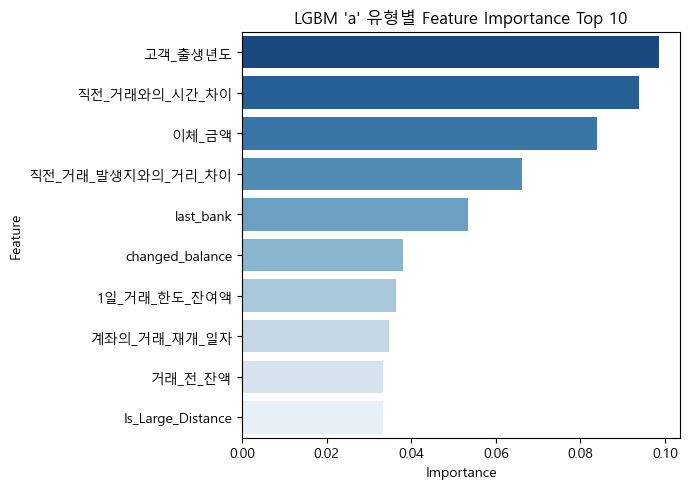

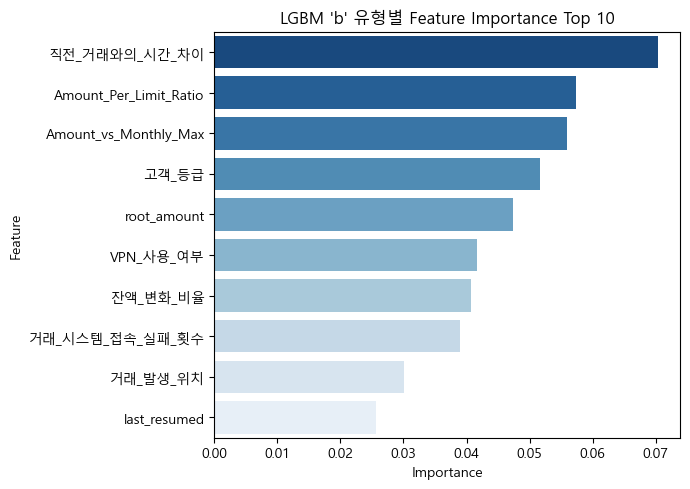

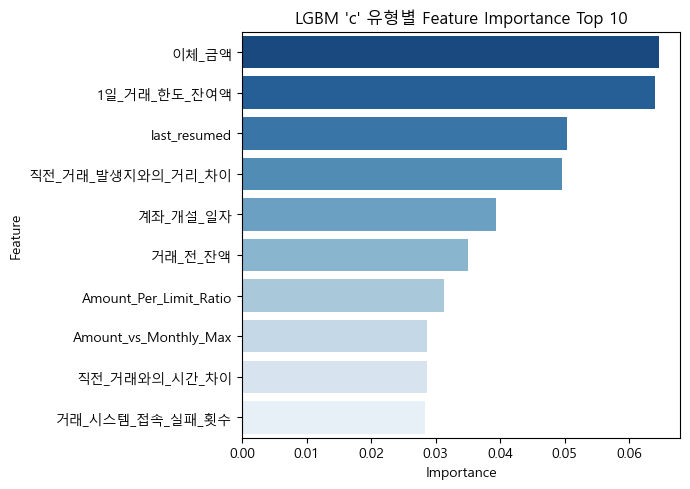

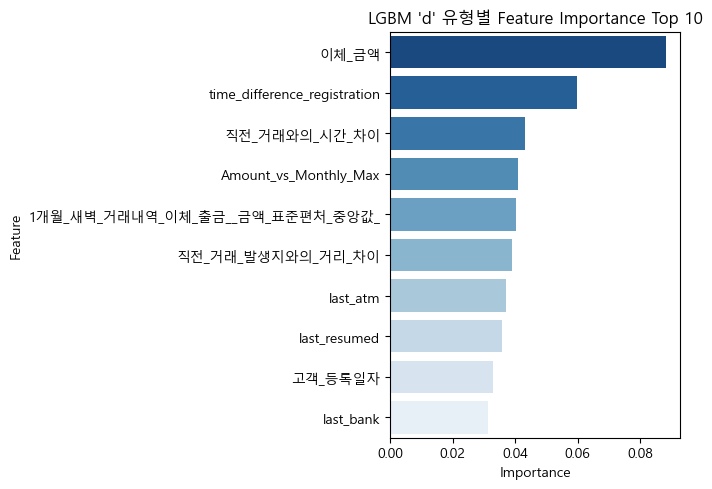

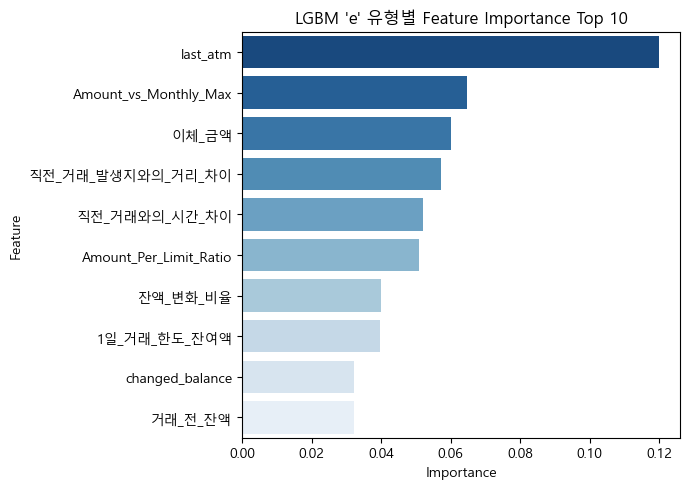

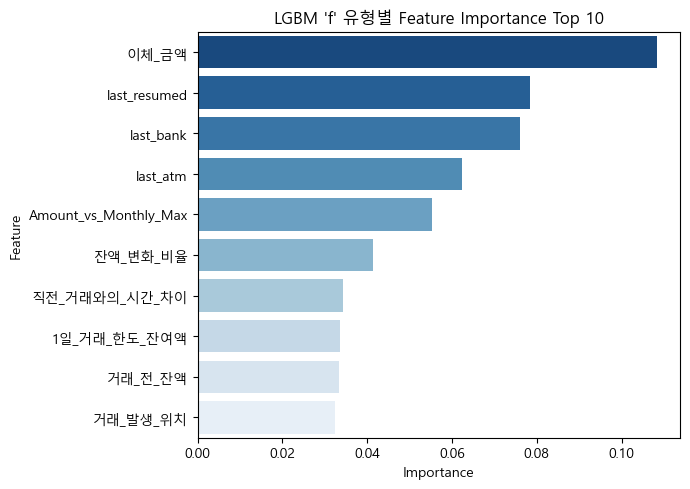

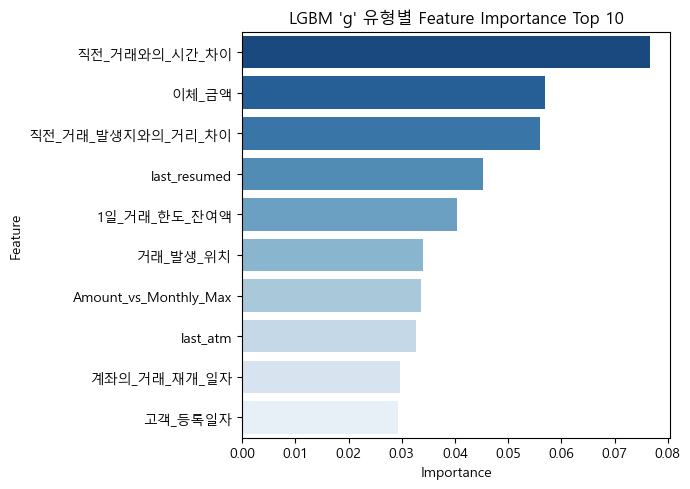

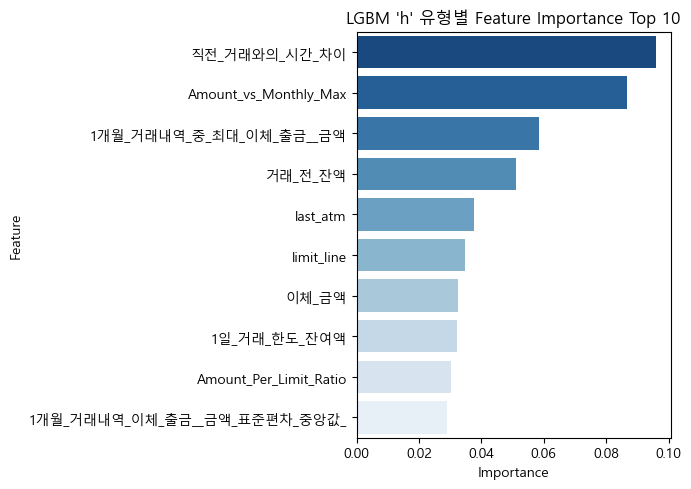

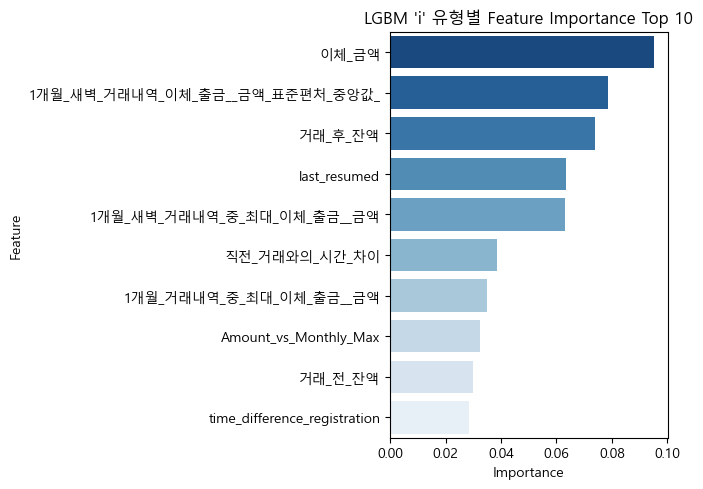

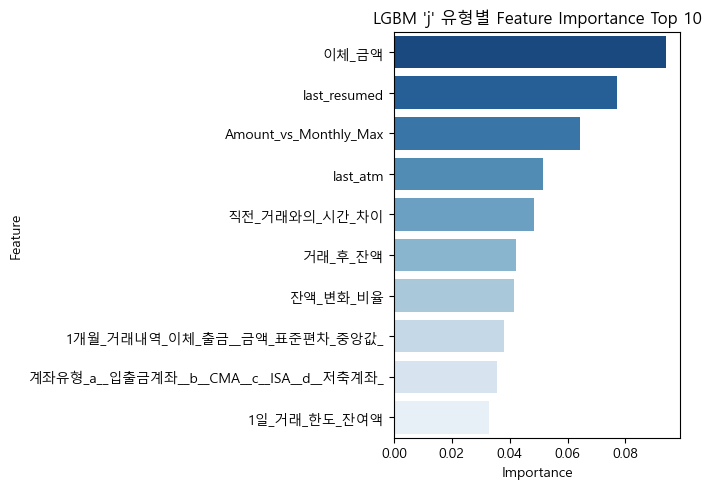

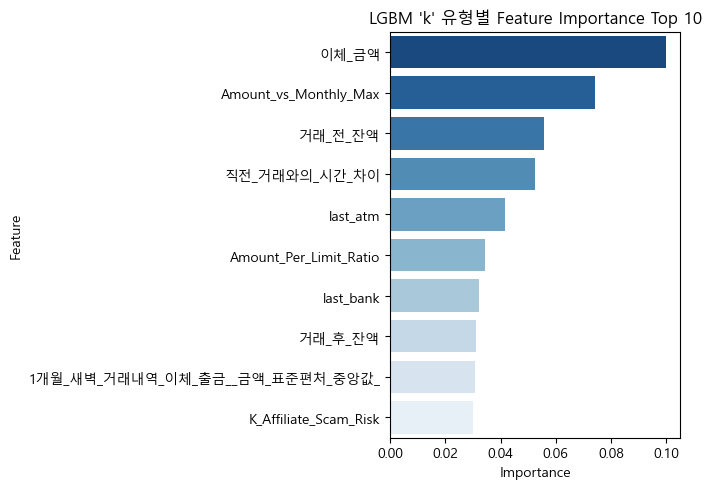

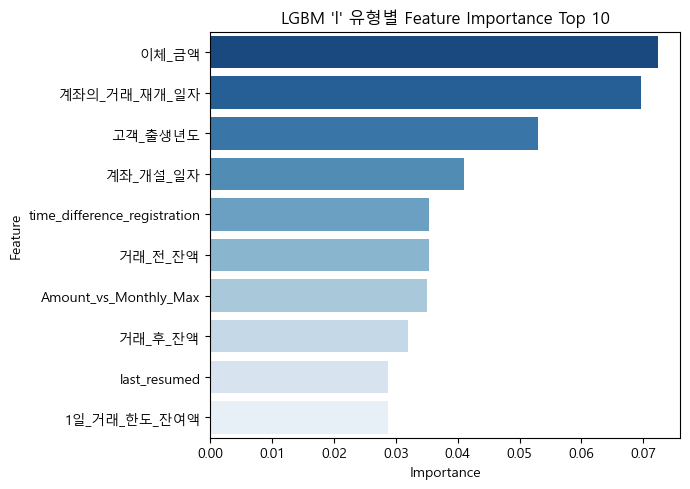

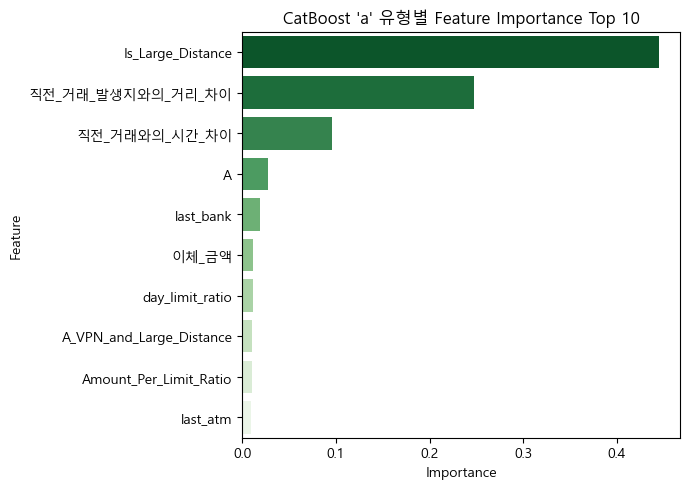

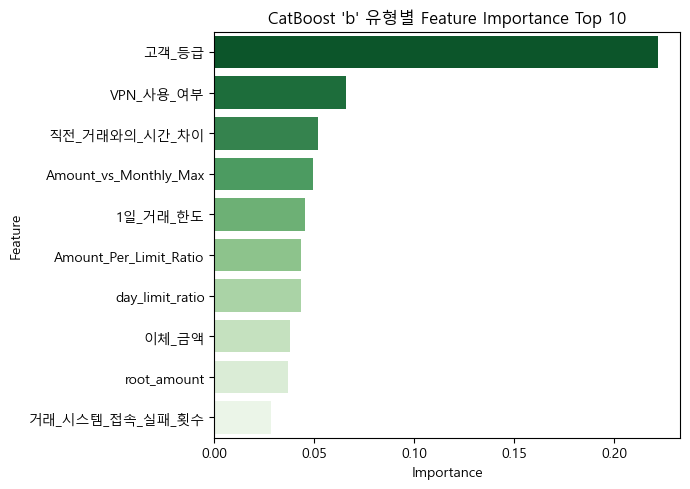

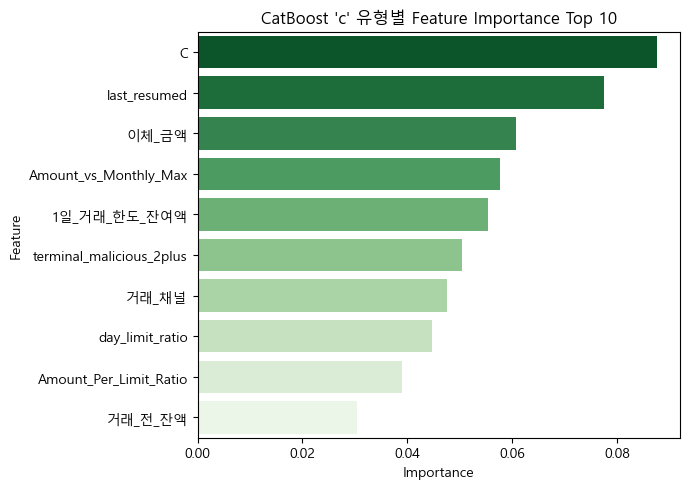

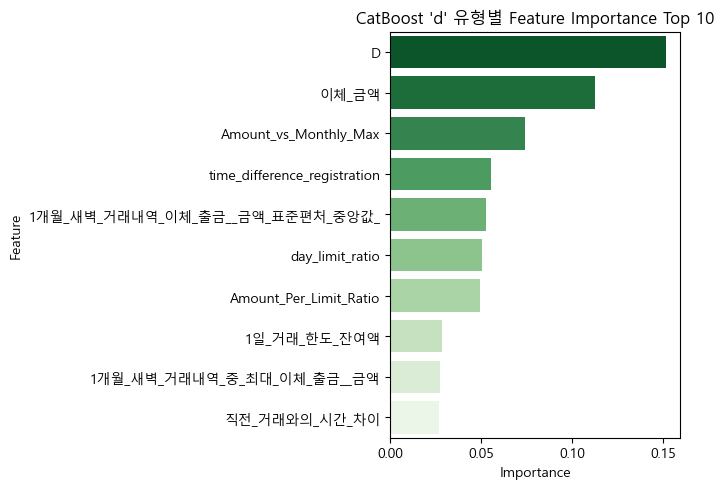

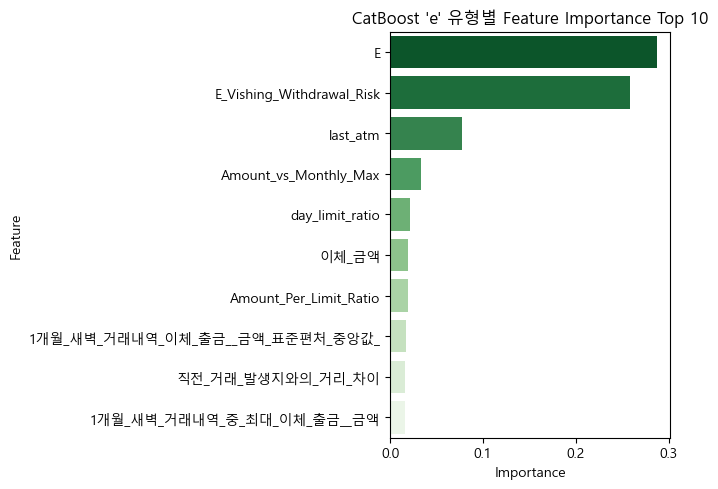

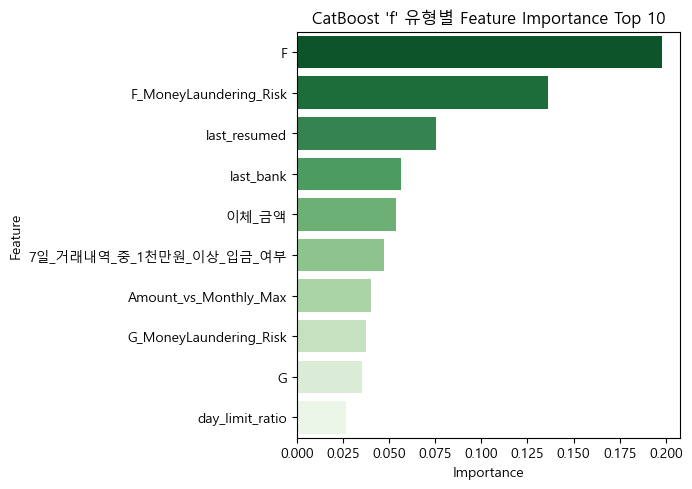

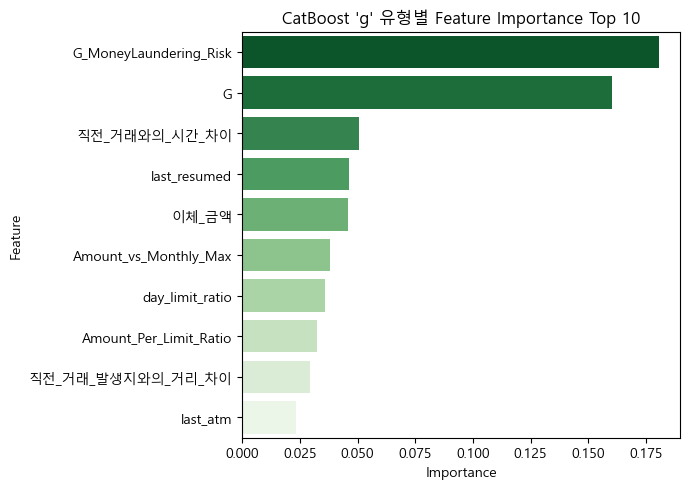

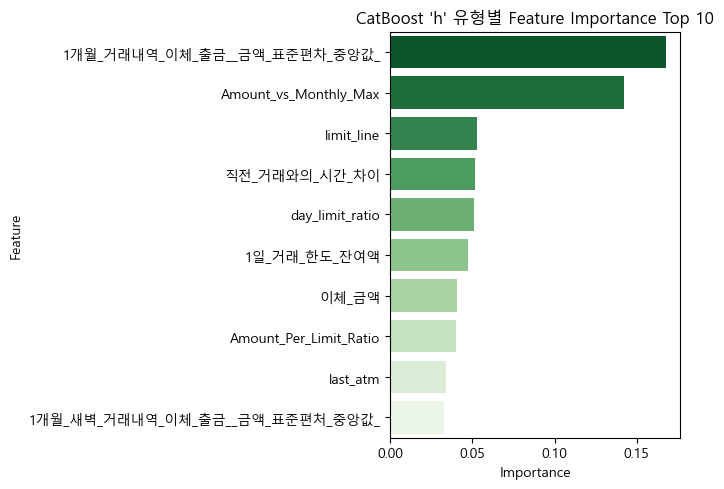

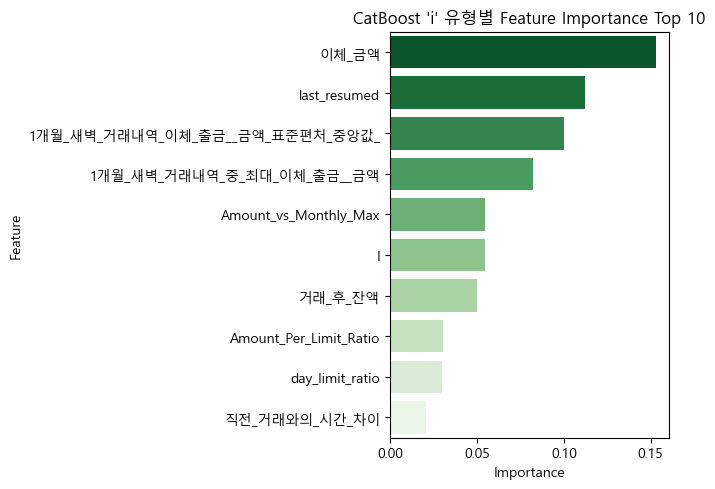

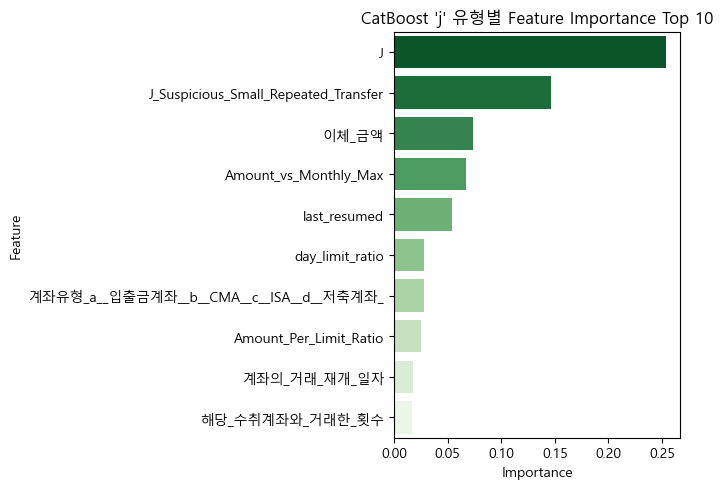

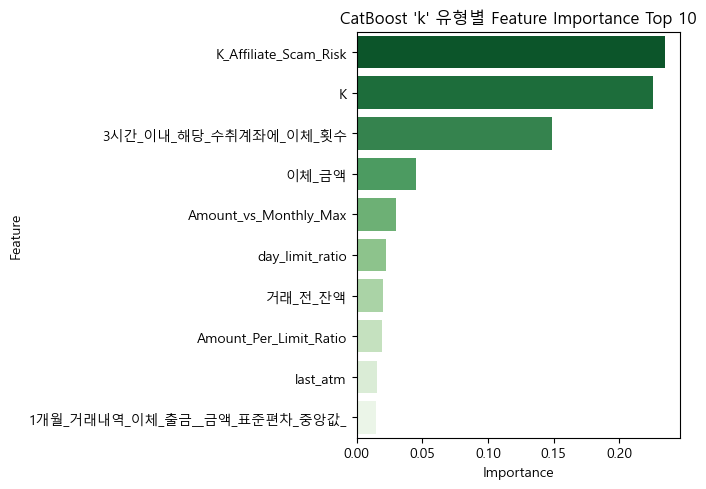

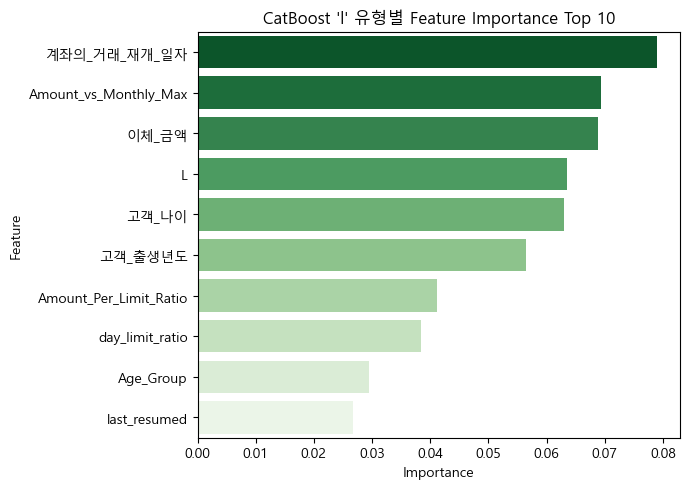

In [22]:
import matplotlib.pyplot as plt
import seaborn as sns

# lgbm_importance와 cat_importance 모두 같은 방식 사용 가능
# 여기서는 lgbm_importance 예시로 설명 (cat_importance로 바꿔도 동작)

# 모델명에서 유형 라벨만 추출 (예: 'a_0' → 'a')
def get_label_from_model(model_name):
    return model_name.split('_')[0]

# 각 유형별 상위 10개 피처 중요도 시각화 (LGBM)
for label in fraud_labels[:-1]:  # 'm' 제외
    imp = lgbm_importance[lgbm_importance['model'].str.startswith(label+'_')]
    # 동일 feature별 평균 importance (앙상블 여러 개라서)
    avg_imp = imp.groupby('feature')['importance'].mean().sort_values(ascending=False).head(10)
    plt.figure(figsize=(7, 5))
    sns.barplot(x=avg_imp.values, y=avg_imp.index, palette='Blues_r')
    plt.title(f"LGBM '{label}' 유형별 Feature Importance Top 10")
    plt.xlabel("Importance")
    plt.ylabel("Feature")
    plt.tight_layout()
    plt.show()

# (CatBoost도 동일하게)
for label in fraud_labels[:-1]:
    imp = cat_importance[cat_importance['model'].str.startswith(label+'_')]
    avg_imp = imp.groupby('feature')['importance'].mean().sort_values(ascending=False).head(10)
    plt.figure(figsize=(7, 5))
    sns.barplot(x=avg_imp.values, y=avg_imp.index, palette='Greens_r')
    plt.title(f"CatBoost '{label}' 유형별 Feature Importance Top 10")
    plt.xlabel("Importance")
    plt.ylabel("Feature")
    plt.tight_layout()
    plt.show()

